#CH5. 회귀

##1. 소개

지도학습은 두가지 유형으로 나뉜다.

분류 vs. 회귀

분류는 예측값이 카테고리와 같은 이산형 클래스 값이고, 회귀는 연속형 숫자 값이다.

여러가지 회귀 중에서 선형 회귀가 가장 많이 사용된다. 선형 회귀는 실제값과 예측값의 차이를 최소화하는 직선형 회귀선을 최적화하는 방식이다.

선형 회귀 모델은 규제
(Regularization) 방법에 따라 다시 별도의 유형으로 나뉠 수 있습니다. 규제는 일반적인 선형 회귀의
과적합 문제를 해결하기 위해서 회귀 계수에 페널티 값을 적용하는 것을 말합니다. 대표적인 선형 회귀
모델은 다음과 같다.

- 일반 선형 회귀: 예측값과 실제 값의 RSS(Residual Sum of Squares)# 최소화할 수 있도록 회귀 계수를 최적화하며, 규
제(Regularization)를 적용하지 않은 모델입니다.
-  릿지(Ridge)： 릿지 회귀는 선형 회귀에 L2 규제를 추가한 회귀 모델입니다. 릿지 회귀는 L2 규제를 적용하는데, L2 규제
는 상대적으로 큰 회귀 계수 값의 예측 영향도를 감소시키기 위해서 회귀 계수값을 더 작게 만드는 규제 모델입니다.
- 라쏘(Lasso)： 라쏘 회귀는 선형 회귀에 L1 규제를 적용한 방식입니다. L2 규제가 회귀 계수 값의 크기를 줄이는 데 반해,
L1 규제는 예측 영향력이 작은 피처의 회귀 계수를 0으로 만들어 회귀 예측 시 피처가 선택되지 않게 하는 것입니다. 이러
한 특성 때문에 L1 규제는 피처 선택 기능으로도 불립니다.
- 엘라스틱넷(티asticNet)： L2, L1 규제를 함께 결합한 모델입니다. 주로 피처가 많은 데이터 세트에서 적용되며, L1 규제로
피처의 개수를 줄임과 동시에 L2 규제로 계수 값의 크기를 조정합니다.
- 로지스틱 회귀(Logistic Regression)： 로지스틱 회귀는 회귀라는 이름이 붙어 있지만, 사실은 분류에 사용되는 선형 모델
입니다. 로지스틱 회귀는 매우 강력한 분류 알고리즘입니다. 일반적으로 이진 분류뿐만 아니라 희소 영역의 분류, 예를 들어 텍스트 분류와 같은 영역에서 뛰어난 예측 성능을 보입니다.


##2. 단순 선형 회귀를 통한 회귀 이해

단순 선형 회귀는 독립변수도 하나, 종속변수도 하나인 선형 회귀이다.

예시) 주택 가격이 주택의 크기로만 결정된다고 하면, 일반적으로 주택의 크기가 크면 가격이 높아지는 경향이 있기에 아래와 같이 선형의 관계로 표현할 수 있다.


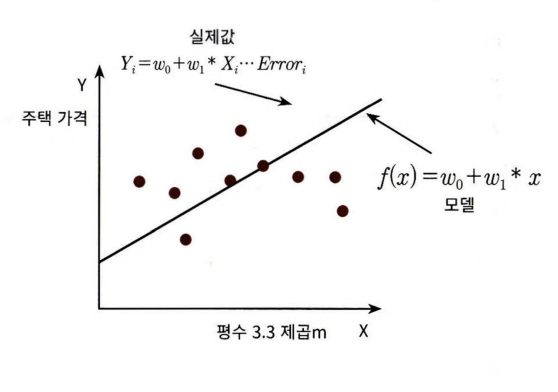

독립변수가 1개인 단순 선형 회귀에서는 이 기울기 w1와 절편 w0을 회귀 계수로 지칭한다.

회귀모델: $\hat{Y} = w_0 + w_1*X$

실제 주택 가격:  $\hat{Y} = w_0 + w_1*X+ 오류값$

위의 오류값을 **잔차**라고 한다. 최적의 회귀 모델을 만든다는 것은 전체 데이터의 잔차의 합이 최소가 되는 모델을 만든다는 의미이다.

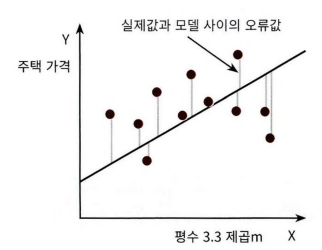

단순히 오류의 합을 더하면 +와 -가 상쇄되어 오류의 합이 줄어들 수 있다. 따라서 보통 오류의 합을 계산할 때는 절댓값을 취해서 더하거나, 오류 값의 제곱을 구해서 더하는 방식을 취한다. 일반적으로 미분 등의 계산을 편리하게 하기 위해서 RSS 방식으로 오류 합을 구한다.

$Error^2 = RSS$

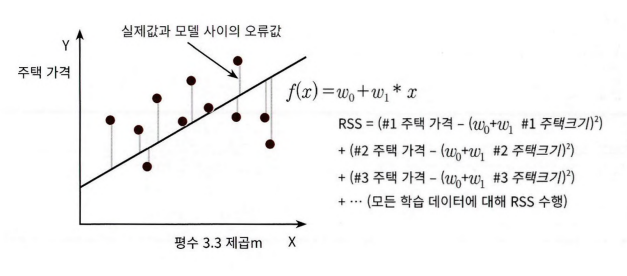

회귀에서 $RSS$는 비용이며, w변수(회귀 계수)로 구성되는 RSS를 비용함수라고 한다. 머신러닝 회귀 알고리즘은 데이터를 계속 학습하면서 이 비용함수가 반환하는 값을 지속해서 감소시키고 최종적으로는 더 이상 감소하지 않는 최소의 오류값을 구하는 것이다. 비용 함수를 $손실함수$라고도 한다.

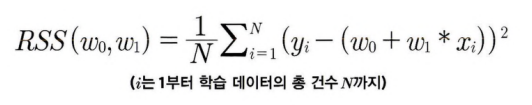

##3. 비용 최소화하기 - 경사 하강법 (Gradient Descent) 소개

경사하강법은 '데이터를 기반으로 알고리즘이 스스로 학습한다'는 머신러닝의 개념을 가능하게 만들어준 핵심 기법의 하나이다.

경사 하강법의 핵심은 "어떻게 하면 오류가 작아지는 방향으로 W값을 보정할 수 있을까?"이다.

비용 함수가 다음 그림과 같은 포물선 형태의 2차 함수라면 경사 하강법은
최초 w에서부터 미분을 적용한 뒤 이 미분 값이 계속 감소하는 방향으로 순차적으로 w를 업데이트합
니다. 마침내 더 이상 미분된 1차 함수의 기울기가 감소하지 않는 지점을 비용 함수가 최소인 지점으로
간주하고 그때의 파를 반환합니다.

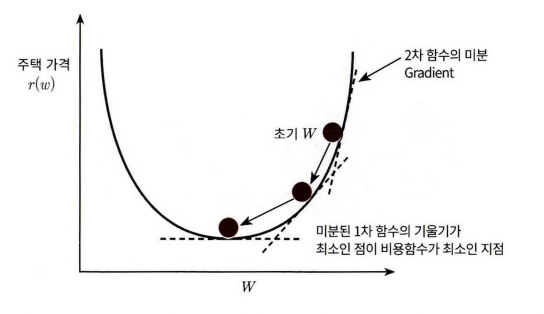

비용 함수 $RSS(w0,w1)$를 편의상 $R(w)$으로 지칭하자. $R(w)$는 변수가 $w$파라미터로 이루어진 함수이다 $R(w)$는 $w0, w1$를 각각 가지고 있기 때문에 각 변수에 편미분을 적용해야 한다.

1. $w1, w0$를 임의의 값으로 설정하고 첫 비용 함수의 값을 계산한다.
2. $w1$을 $$w1+-\eta \frac{2}{N} \sum_{i=1}^{N} x_i * (\text{실제값}_i - \text{예측값}_i)$$,$w0$를 $$w0+-\eta \frac{2}{N} \sum_{i=1}^{N} x_i * (\text{실제값}_i - \text{예측값}_i)$$으로 업데이트한 후 다시 비용 함수의 값을 계산한다.
3. 비용 함수가 감소하는 방향성으로 주어진 횟수만큼 Step2를 반복하면서 $w1$와 $w0$를 계속 업데이트한다.

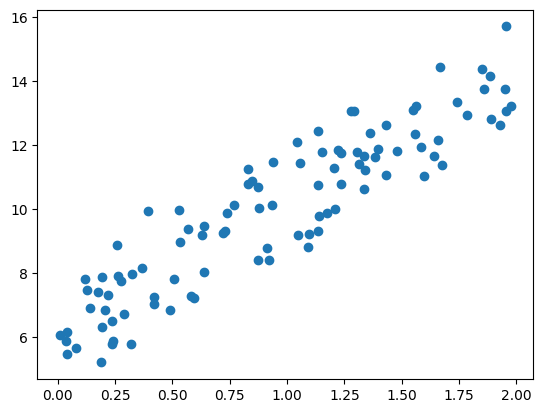

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

np.random.seed(0)
#y = 4X+6을 근사(w1=4, w0=6) 임의의 값은 노이즈를 위해 만듦
X = 2* np.random.rand(100,1)
y = 6 + 4 * X + np.random.randn(100,1)

#X, y 데이터 세트 산점도로 시각화
plt.scatter(X, y)

In [2]:
def get_cost(y,y_pred):
  N = len(y)
  cost = np.sum(np.square(y-y_pred))/N
  return cost

In [16]:
def get_weight_updates(w1,w0,X,y,learning_rate=0.01):
  N = len(y)
  #먼저 w1_update, w0_update를 각각 w1, w0의 shape와 동일한 크기를 가진 0값으로 초기화
  w1_update = np.zeros_like(w1)
  w0_update = np.zeros_like(w0)
  #예측 배열 계산하고 예측과 실제 값의 차이 계산
  y_pred = np.dot(X, w1.T)+w0
  diff = y-y_pred
  #w0_update를 dot 행렬 연산으로 구하기 위해 모두 1값을 가진 행렬 생성
  w0_factors = np.ones((N,1))
  #w1과 w0을 업데이트할 w1_update와 w0_update계산
  w1_update = -(2/N)*learning_rate*(np.dot(X.T, diff))
  w0_update = -(2/N)*learning_rate*(np.dot(w0_factors.T, diff))

  return w1_update, w0_update

In [17]:
# 입력 인자 iters로 주어진 횟수만큼 반복적으로 w1와 w0를 업데이트 적용
def gradient_descent_steps(X,y,iters=10000):
  #w0과 w1을 모두 0으로 초기화
  w0=np.zeros((1,1))
  w1=np.zeros((1,1))

  #인자로 주어진 iter만큼 반복적으로 get_weight_updates() 호출해 w1,w0 업데이트 수행
  for ind in range(iters):
    w1_update, w0_update = get_weight_updates(w1,w0,X,y,learning_rate=0.01)
    w1 = w1-w1_update
    w0 = w0-w0_update

  return w1, w0

In [18]:
from typing import NoReturn
def get_cost(y, y_pred):
  N = len(y)
  cost = np.sum(np.square(y-y_pred))/N
  return cost

w1,w0 = gradient_descent_steps(X,y,iters=1000)
print("w1:{0:.3f} w0:{1:.3f}".format(w1[0,0], w0[0,0]))
y_pred = w1[0,0]*X+w0
print('Gradient Descent Total Cost:{0:.4f}'.format(get_cost(y,y_pred)))

w1:4.022 w0:6.162
Gradient Descent Total Cost:0.9935


실제 선형식인 $y=4X+6$과 유사하게 $w1=4.022$이고, $w0=6.162$가 도출되었다.

예측 오류 비용은 0.9935이다.

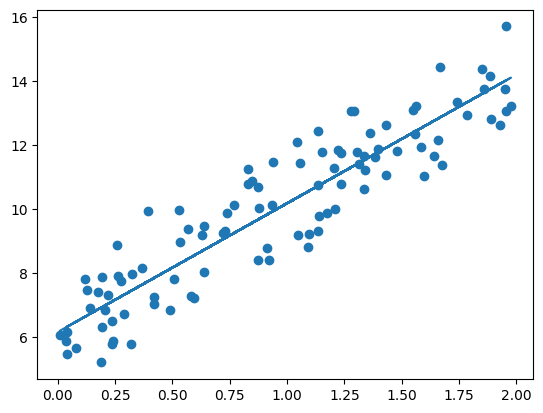

In [19]:
plt.scatter(X,y)
plt.plot(X,y_pred)

일반적으로 경사 하강법은 모든 학습데이터에 대해 반복적으로 비용함수 최소화를 위한 값을 업데이트하기 때문에 수행시간이 매우 오래 걸린다는 단점이 있다.

그 때문에 실전에서는 대부분 확률적 경사 하강법을 이용한다.

확률적 경사하강법은 전체 입력 데이터로 w가 업데이트되는 값을 계산하는 것이 아니라 일부 데이터만 이용해 w가 업데이트되는 값을 계산하므로 경사 하강법에 비해 빠른 속도를 보장한다.

In [20]:
def stochastic_gradient_descent_steps(X,y,batch_size=10, iters=1000):
  w0=np.zeros((1,1))
  w1=np.zeros((1,1))

  for ind in range(iters):
    np.random.seed(ind)
    #전체 X,y데이터에서 랜덤하게 batch_size만큼 데이터를 추출해 sample_X, sample_y로 저장
    stochastic_random_index = np.random.permutation(X.shape[0])
    sample_X = X[stochastic_random_index[0:batch_size]]
    sample_y = y[stochastic_random_index[0:batch_size]]
    #랜덤하게 batch_size만큼 추출된 데이터 기반으로 w1_update, w0_update계산 후 업데이트
    w1_update, w0_update = get_weight_updates(w1, w0, sample_X, sample_y, learning_rate=0.01)
    w1 = w1-w1_update
    w0 = w0-w0_update

  return w1, w0

In [21]:
w1,w0 = stochastic_gradient_descent_steps(X,y, iters=1000)
print('w1:', round(w1[0,0],3), 'w0:', round(w0[0,0],3))
y_pred = w1[0,0]*X+w0
print('Stochastic Gradient Descent Total Cost:{0:.4f}'.format(get_cost(y,y_pred)))

w1: 4.028 w0: 6.156
Stochastic Gradient Descent Total Cost:0.9937


다중선형회귀

$\hat{Y} = w_0+w_1*X_1+ ... +w_{100}*X_{100}$

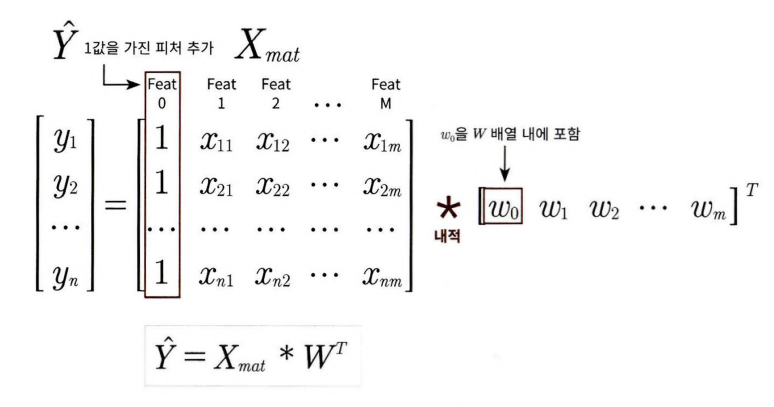

## 4. 사이킷런 LinearRegression을 이용한 보스턴 주택 가격 예측

- LinearRegression 클래스-Ordinary Least Squares

LinearRegression 클래스는 예측값과 실제 값의 RSS(Residual Sum of Squares)를 최소화해
OLS(Ordinary Least Squares) 추정 방식으로 구현한 클래스

fit()메서드로 X,y배열을 입력받으면 회귀계수인 W를 coef_속성에 저장한다.

In [22]:
from sklearn.linear_model import LinearRegression
linear_regression_model = LinearRegression(fit_intercept=True, n_jobs=1)

- 입력 파라미터
1. fit_intercept: 불린 값으로 디폴트는 True이다. intercept 값을 계산할 것인지 말지를 지정한다. 만일 False로 지정하면 intercept가 사용되지 않고 0으로 지정된다.
2. normalize: 불린 값으로 디폴트는 False이다. fit_intercept가 False인 경우에는 이 파라미터가 무시된다. 만일 True이면 회귀를 수행하기 전에 입력 데이터 세트를 정규화한다.

- 속성
1. coef_: fit()메서드를 수행했을 때 회귀 계수가 배열 형태로 저장하는 속성. Shape는 (Target 값 개수, 피처 개수)
2. intercept_: intercept 값

- 회귀 평가 지표

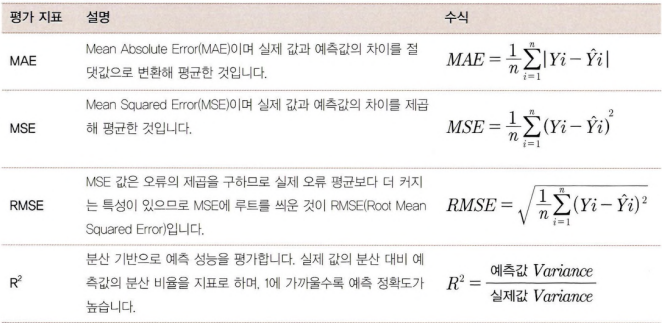

이 밖에 MSE나 RMSE에 로그를 적용한 MSLE와 RMSLE도 사용한다.

사이킷런은 아쉽게도 RMSE를 제공하지 않는다. RMSE를 구하기 위해서는 MSE에 제곱근을 씌워 계산하는 함수를 직접 만들어야 한다.

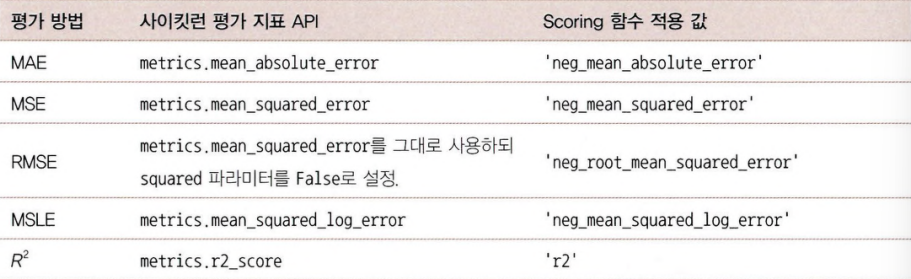

LinearRegression을 이용해 보스턴 주택 가격 회귀 구현

In [25]:
data_url = "http://lib.stat.cmu.edu/datasets/boston"

raw_df = pd.read_csv(data_url, sep=r"\s+", skiprows=22, header=None)

data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])

target = raw_df.values[1::2, 2]

In [26]:
feature_names = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT']

bostonDF = pd.DataFrame(data, columns=feature_names)

bostonDF['PRICE'] = target

print('Boston 데이터 세트 크기 :', bostonDF.shape)

display(bostonDF.head())

Boston 데이터 세트 크기 : (506, 14)


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,PRICE
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33,36.2


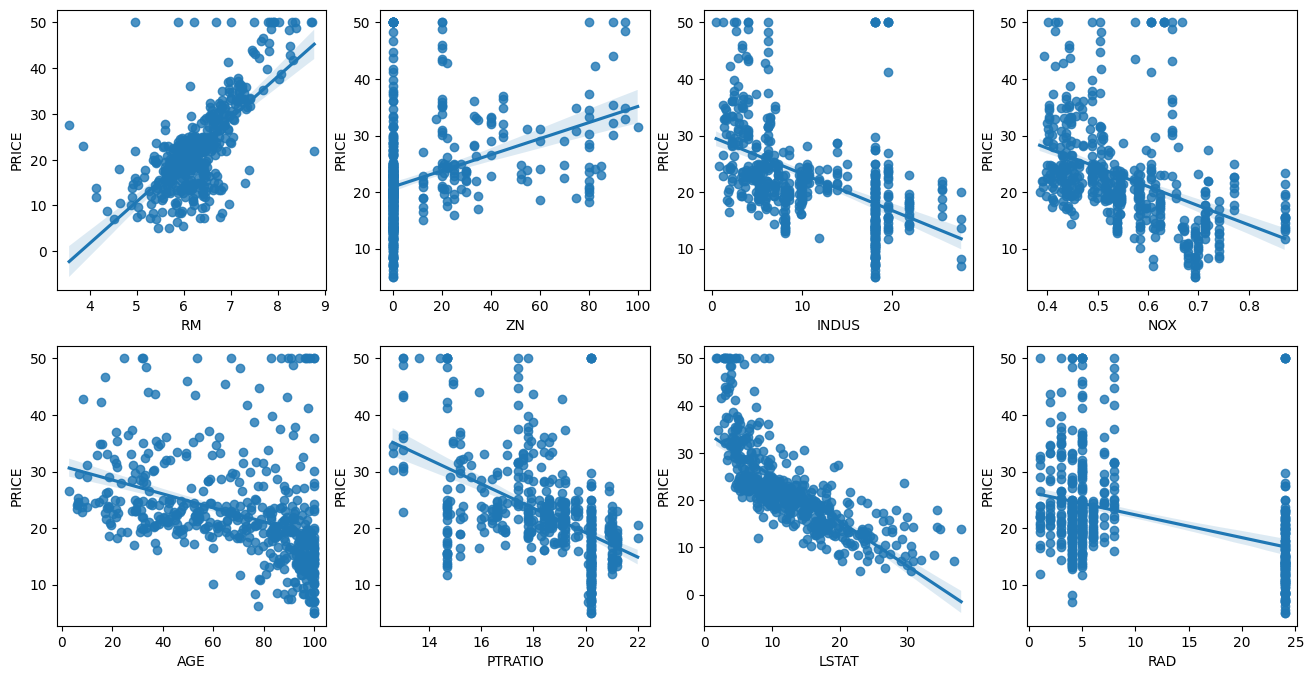

In [27]:
# 2개의 행과 4개의 열을 가진 subplots를 이용. axs는 4x2개의 ax를 가짐
fig, axs = plt.subplots(figsize=(16,8), ncols=4, nrows=2)
lm_features = ['RM', 'ZN', 'INDUS', 'NOX', 'AGE','PTRATIO', 'LSTAT', 'RAD']

for i, feature in enumerate(lm_features):
    row = int(i/4)
    col = i%4
    #시본의 regplot을 이용해 산점도와 선형 회귀 직선을 함께 표현
    sns.regplot(x=feature, y='PRICE', data=bostonDF, ax=axs[row][col])

방의 개수 (RM)는 양 방향의 선형성이 가장 크다. 즉, 방의 크기가 클수로 가격이 증가하는 모습을 확연히 보여준다.

하위계층의 비율(LSTAT)은 음 방향의 선형성이 가장 크다. LSTAT이 적을수록 PRICE가 증가하는 모습이 보인다.

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

y_target = bostonDF['PRICE']
X_data = bostonDF.drop(['PRICE'], axis=1, inplace=False)

X_train, X_test, y_train, y_test = train_test_split(X_data, y_target, test_size=0.3, random_state=156)

#선형 회귀 OLS로 학습/예측/평가 수행
lr = LinearRegression()
lr.fit(X_train, y_train)
y_preds = lr.predict(X_test)
mse = mean_squared_error(y_test, y_preds)
rmse = np.sqrt(mse)

print('MSE : {0:.3f}, RMSE : {1:.3F}'.format(mse, rmse))
print('Variance score:{0:.3f}'.format(r2_score(y_test, y_preds)))

MSE : 17.297, RMSE : 4.159
Variance score:0.757


In [29]:
print('절편값:',lr.intercept_)
print('회귀 계수 값:', np.round(lr.coef_, 1))

절편값: 40.995595172164826
회귀 계수 값: [ -0.1   0.1   0.    3.  -19.8   3.4   0.   -1.7   0.4  -0.   -0.9   0.
  -0.6]


In [30]:
# 회귀 계수를 큰 값 순으로 정렬하기 위해 Series로 생성. 인덱스 칼럼명에 유의
coeff = pd.Series(data=np.round(lr.coef_,1), index=X_data.columns)
coeff.sort_values(ascending=False)

,0
RM,3.4
CHAS,3.0
RAD,0.4
ZN,0.1
INDUS,0.0
B,0.0
TAX,-0.0
AGE,0.0
CRIM,-0.1
LSTAT,-0.6


In [31]:
from sklearn.model_selection import cross_val_score

y_target = bostonDF['PRICE']
X_data = bostonDF.drop(['PRICE'], axis=1, inplace=False)
lr = LinearRegression()

#cross_val_score()로 5폴드 세트로 MSE를 구한 뒤 이를 기반으로 다시 RMSE 구함
neg_mse_scores = cross_val_score(lr, X_data, y_target, scoring="neg_mean_squared_error", cv=5)
rmse_scores = np.sqrt(-1 * neg_mse_scores)
avg_rmse = np.mean(rmse_scores)

#cross_val_score(scoring='neg_mean_squared_error')로 반환된 값은 모두 음수
print(' 5 folds의 개별 Negative MSE scores: ', np.round(neg_mse_scores, 2))
print(' 5 folds의 개별 RMSE scores : ', np.round(rmse_scores, 2))
print(' 5 folds의 평균 RMSE : {0:.3f} '.format(avg_rmse))

 5 folds의 개별 Negative MSE scores:  [-12.46 -26.05 -33.07 -80.76 -33.31]
 5 folds의 개별 RMSE scores :  [3.53 5.1  5.75 8.99 5.77]
 5 folds의 평균 RMSE : 5.829 


## 5. 다항 회귀와 과(대)적합/과소적합 이해

다항 회귀 이해

다항회귀: 독립변수의 단항식이 아닌 2차, 3차 방정식과 같은 다항식으로 표현되는 것

<예시>
$$ y=w_0+w_1*x_1+w_2*x_2++w_3*x_1x_2+w_4*x_1^2+w_5*x_2^2$$

다항회귀를 비선형 회귀로 혼동하기 쉽지만, 다항 회귀는 선형 회귀이다. 회귀에서 선형/비선형을 나누는 기준은 회귀 계수가 선형/비선형인지에 따르는 것이지 독립변수의 선형/비선형 여부와는 무관하다.

사이킷런은 PolynomialFeatures 클래스를 통해 피처를 Polynomial(다항식) 피처로 변환합니다.

PolynomialFeatures 클래스는 degree 파라미터를 통해 입력받은 단항식 피처를 degree에 해당하는 다항식 피처로 변환합니다. 다른 전처리 변환클래스와 마찬가지로 PolynomialFeatures 클래스는 fit(),transform() 메서드를 통해 이 같은 변환 작업을 수행합니다. 다음 예제는 PolynomialFeatures를 이용해 단항값[$x_1,x_2$]를 2차 다항값으로[$1,x_1,x_2,x_1^2,x_1x_2, x_2^2$] 변환하는 예제입니다.

In [32]:
from sklearn.preprocessing import PolynomialFeatures
import numpy as np

#다항식으로 변환한 단항식 생성, [[0,1],[2,3]]의 2x2 행렬 생성
X = np.arange(4).reshape(2,2)
print('일차 단항식 계수 피처:\n',X)

#degree=2인 2차 다항식으로 변환하기 위해 PolynomialFeatures를 이용해 변환
poly = PolynomialFeatures(degree=2)
poly.fit(X)
poly_ftr = poly.transform(X)
print('변환된 2차 다항식 계수 피처:\n',poly_ftr)

일차 단항식 계수 피처:
 [[0 1]
 [2 3]]
변환된 2차 다항식 계수 피처:
 [[1. 0. 1. 0. 0. 1.]
 [1. 2. 3. 4. 6. 9.]]


In [33]:
def polynomial_func(X):
  y = 1+2*X[:,0]+3*X[:,0]**2+4*X[:,1]**3
  return y

X = np.arange(4).reshape(2,2)
print('일차 단항식 계수 feature:\n',X)
y = polynomial_func(X)
print('삼차 다항식 결정값:\n',y)

일차 단항식 계수 feature:
 [[0 1]
 [2 3]]
삼차 다항식 결정값:
 [  5 125]


In [34]:
# 3차 다항식 변환
poly_ftr = PolynomialFeatures(degree=3).fit_transform(X)
print('3차 다항식 계수 feature:\n', poly_ftr)

#Linear Regression에 3차 다항식 게수 feature와 3차 다항식 결정값으로 학습 후 회귀 계수 확인
model = LinearRegression()
model.fit(poly_ftr,y)
print('Polynomial 회귀 계수\n', np.round(model.coef_,2))
print('Polynomial 회귀 Shape:', model.coef_.shape)

3차 다항식 계수 feature:
 [[ 1.  0.  1.  0.  0.  1.  0.  0.  0.  1.]
 [ 1.  2.  3.  4.  6.  9.  8. 12. 18. 27.]]
Polynomial 회귀 계수
 [0.   0.18 0.18 0.36 0.54 0.72 0.72 1.08 1.62 2.34]
Polynomial 회귀 Shape: (10,)


In [35]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
import numpy as np

def polynomial_func(X):
  y = 1+2*X[:,0]+3*X[:,0]**2+4*X[:,1]**3
  return y

# Pipeline객체로 Streamline하게 Polynomial Feature 변환과 LinearRegression을 연결
model = Pipeline([('poly', PolynomialFeatures(degree=3)),
                  ('linear', LinearRegression())])

X = np.arange(4).reshape(2,2)
y = polynomial_func(X)

model = model.fit(X,y)

print('Polynomial 회귀 계수\n', np.round(model.named_steps['linear'].coef_,2))

Polynomial 회귀 계수
 [0.   0.18 0.18 0.36 0.54 0.72 0.72 1.08 1.62 2.34]


다항 회귀를 이용한 과소적합 및 과적합 이해

: 다항식의 차수가 높아질수록 매우 복잡한 피처간의 관계까지 모델링이 가능하다. 하지만 다항 회귀의 차수를  높일수록 학습데이터에만 너무 맞춘 학습이 이루어져 정작 테스트 데이터 환경에서는 오히려 예측 정확도가 떨어진다. [과적합의 문제]

In [36]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
%matplotlib inline

#임의의 값으로 구성된 X값에 대해 코사인 변환 값을 반환
def true_fun(X):
  return np.cos(1.5*np.pi*X)


# X는 0부터 1까지 30개의 임의의 값을 순서대로 샘플링한 데이터
np.random.seed(0)
n_samples=30
X = np.sort(np.random.rand(n_samples))

#y값은 코사인 기반의 true_fun()에서 약간의 노이즈 변동 값을 더한 값이다.
y = true_fun(X)+np.random.randn(n_samples)*0.1


Degree1 회귀 계수는 [-1.61]입니다.
Degree 1 MSE는 0.4077289625098685입니다.

Degree4 회귀 계수는 [  0.47 -17.79  23.59  -7.26]입니다.
Degree 4 MSE는 0.04320874987232064입니다.

Degree15 회귀 계수는 [-2.98293000e+03  1.03899390e+05 -1.87416123e+06  2.03716219e+07
 -1.44873283e+08  7.09315363e+08 -2.47065792e+09  6.24561050e+09
 -1.15676510e+10  1.56894936e+10 -1.54006023e+10  1.06457264e+10
 -4.91377530e+09  1.35919645e+09 -1.70380786e+08]입니다.
Degree 15 MSE는 181238256.56423894입니다.


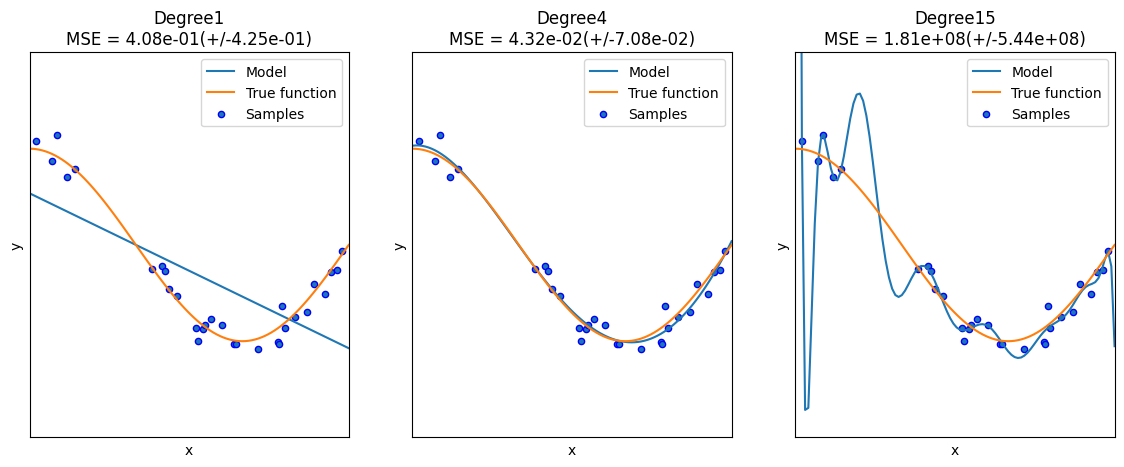

In [40]:
plt.figure(figsize=(14,5))
degrees = [1,4,15]

#다항 회귀의 차수를 1,4,15로 각각 변화시키면서 비교한다.
for i in range(len(degrees)):
  ax = plt.subplot(1,len(degrees), i+1)
  plt.setp(ax, xticks=(),yticks=())

  #개별 degree별로 polynomial 변환합니다.
  polynomial_features = PolynomialFeatures(degrees[i], include_bias=False)
  linear_regression = LinearRegression()
  pipeline = Pipeline([('polynomial_features',polynomial_features),('linear_regression', linear_regression)])
  pipeline.fit(X.reshape(-1,1),y)

  #교차 검증으로 다항회귀를 평가합니다.
  scores = cross_val_score(pipeline, X.reshape(-1,1), y, scoring='neg_mean_squared_error', cv=10)
  #Pipeline을 구성하는 세부 객체를 접근하는 named_steps['객체명']을 이용해 회귀 계수 추출
  coefficients = pipeline.named_steps['linear_regression'].coef_
  print('\nDegree{0} 회귀 계수는 {1}입니다.'.format(degrees[i], np.round(coefficients,2)))
  print('Degree {0} MSE는 {1}입니다.'.format(degrees[i], -1*np.mean(scores)))

  #0부터 1까지 테스트 데이터 세트를 100개로 나눠 예측을 수행합니다.
  #테스트 데이터 세트에 회귀 예측을 수행하고 예측 곡선과 실제 곡선을 그려서 비교한다.
  X_test = np.linspace(0,1,100)

  #예측값 곡선
  plt.plot(X_test, pipeline.predict(X_test[:,np.newaxis]), label='Model')

  #실제 값 곡선
  plt.plot(X_test, true_fun(X_test),'-', label='True function')
  plt.scatter(X,y,edgecolor='b',s=20,label='Samples')

  plt.xlabel('x'); plt.ylabel('y'); plt.xlim((0,1));plt.ylim((-2,2));plt.legend(loc='best')
  plt.title('Degree{}\nMSE = {:.2e}(+/-{:.2e})'.format(degrees[i], -scores.mean(), scores.std()))

plt.show()

파란색으로 표현된 예측 곡선은 다항 회귀 예측 곡선이다. 노란색으로 표현된 곡선은 실제 데이터 세트 X,Y의 코사인 곡선이다.

학습 데이터는 0부터 1까지의 30개의 임의의 X 값과 그에 따른 코사인 Y
값에 잡음을 변동 값으로 추가해 구성했으며 MSE(Mean Squared Error) 평가는 학습 데이터를 10개
의 교차 검증 세트로 나누어 측정해서 평균한 것



편향-분산 트레이드오프(Bias-Variance Trade off)

편향-분산 트레이드오프는 머신러닝이 극복해야 할 가장 중요한 이슈 중의 하나입니다. 앞의 Degree
1과 같은 모델은 매우 단순화된 모델로서 지나치게 한 방향성으로 치우친 경향이 있습니다. 이런 모델
을 고편향(High Bias)성을 가졌다고 표현합니다. 반대로 Degree 15와 같은 모델은 학습 데이터 하나
하나의 특성을 반영하면서 매우 복잡한 모델이 되었고 지나치게 높은 변동성을 가지게 되었습니다. 이
런 모델을 고분산(High Variance)성을 가졌다고 표현합니다.

편향을 낮추고 분산을 높이면서 전체 오류가 가장 낮아지는 **골디락스**지점을 통과하며 분산을 지속적으로 높이면 전체 오류값이 오히려 증가하며 예측 성능이 다시 저하된다.

높은 편향/ 낮은 분산에서 과소적합되기 쉬우며 낮은 편향/높은 분산에서 과적합되기 쉽다. 편향과 분산이 서로 트레이드오프를 이루며 오류 Cost값이 최대로 낮아지는 모델을 구축하는 것이 가장 효율적인 머신러닝 예측 모델을 만드는 방법이다.